# 🏋️ GYM — Clasificación con Árboles de Decisión, Random Forest y XGBoost

**Dataset:** Gym Customer Dataset  
**Objetivo:** Predecir si un cliente está satisfecho (`Satisfecho = 1`) o no (`Satisfecho = 0`)  
**Modelos:** Decision Tree · Random Forest · XGBoost  

---

## 🗺️ Estructura del notebook

| Sección | Contenido |
|---|---|
| 1 | Imports y carga de datos |
| 2 | Decision Tree Classifier |
| 3 | Random Forest Classifier |
| 4 | XGBoost Classifier |
| 5 | Comparativa final de los 3 modelos |
| 6 | Conclusión de negocio |

---
> **Nota de aprendizaje:** Cada parámetro tiene un comentario explicando qué hace.  
> Cada modelo tiene sus propias métricas, gráficos e interpretación.  
> Al final comparamos los 3 modelos en una tabla.


---
## 📦 Sección 1 — Imports y carga de datos

Todos los imports al inicio. Buena práctica fundamental: nunca importes en medio del notebook.


In [1]:
# ============================================================
# IMPORTS — todos al inicio, una sola vez
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier, plot_importance

# Preprocesamiento y validación
from sklearn.model_selection import train_test_split, cross_val_score

# Métricas — iguales para los 3 modelos (agnósticas al algoritmo)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ============================================================
# CARGA DE DATOS
# ============================================================
data = pd.read_excel(r"dataset_didactico_machine_learning - ALUMNOS - copia.xlsx")

print(f"Filas: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Filas: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


In [3]:
# ============================================================
# DEFINICIÓN DE FEATURES Y TARGET
# ============================================================
# Features (X): variables que el modelo usa para predecir
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]

# Target (y): lo que queremos predecir
# 0 = No Satisfecho | 1 = Satisfecho
y = data["Satisfecho"]

print("Distribución del target:")
print(y.value_counts())
print(f"\nProporción: {y.value_counts(normalize=True).round(2).to_dict()}")

Distribución del target:
Satisfecho
0    156
1    144
Name: count, dtype: int64

Proporción: {0: 0.52, 1: 0.48}


In [4]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% para test, 80% para entrenar
    stratify=y,          # mantiene la proporción de clases en ambos conjuntos
    random_state=42      # semilla para reproducibilidad
)

print(f"Train: {X_train.shape[0]} muestras")
print(f"Test:  {X_test.shape[0]} muestras")

Train: 240 muestras
Test:  60 muestras


---
## 🌳 Sección 2 — Decision Tree Classifier

### ¿Qué es un árbol de decisión?
Imagina un juego de 20 preguntas. El árbol hace una pregunta a la vez  
(¿Asistencias > 13.5?) y según la respuesta va al siguiente nodo,  
hasta llegar a una hoja con la predicción final.

### Mapa conceptual
```
Estadística básica
      ↓
Árbol de Decisión  ← estamos aquí
      ↓
Random Forest (muchos árboles)
      ↓
XGBoost (árboles que se corrigen entre sí)
```

---
### 🔍 Paso 1: ¿Cuánta profundidad necesita el árbol?

Antes de entrenar, demostramos con una **curva de validación** por qué elegimos `max_depth=2`.


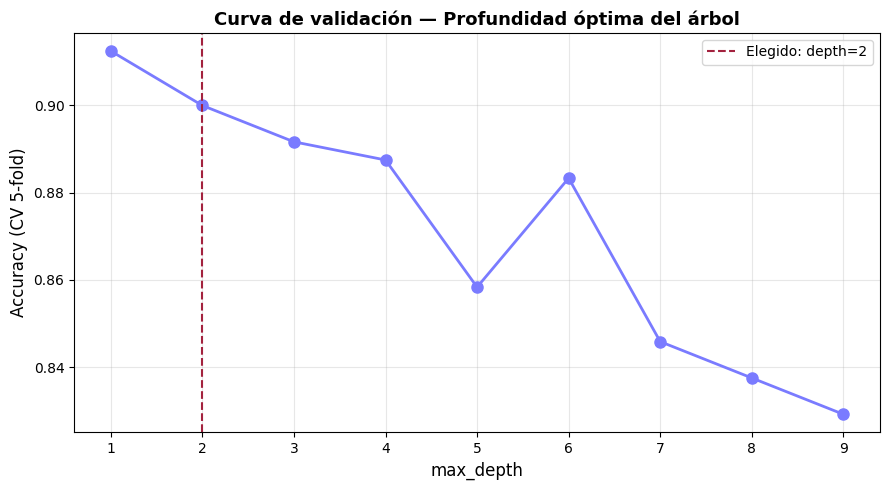

Profundidad con mayor accuracy en CV: 1
Accuracy en CV con depth=2: 90.00%

Con depth > 3 el modelo empieza a memorizar el train (overfitting)


In [5]:
# ============================================================
# CURVA DE VALIDACIÓN — justifica la elección de max_depth
# ============================================================
# Probamos profundidades del 1 al 9 usando validación cruzada (5 folds)
# Esto evita elegir depth=10 porque 'parece que aprende más'

depths = range(1, 10)
val_scores = []

for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(t, X_train, y_train, cv=5, scoring="accuracy").mean()
    val_scores.append(score)

plt.figure(figsize=(9, 5))
plt.plot(depths, val_scores, marker="o", color="#7a7bff", linewidth=2, markersize=8)
plt.axvline(x=2, color="#a3223e", linestyle="--", linewidth=1.5, label="Elegido: depth=2")
plt.xlabel("max_depth", fontsize=12)
plt.ylabel("Accuracy (CV 5-fold)", fontsize=12)
plt.title("Curva de validación — Profundidad óptima del árbol", fontsize=13, fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = list(depths)[val_scores.index(max(val_scores))]
print(f"Profundidad con mayor accuracy en CV: {best_depth}")
print(f"Accuracy en CV con depth=2: {val_scores[1]:.2%}")
print("\nCon depth > 3 el modelo empieza a memorizar el train (overfitting)")

---
### 🔍 Paso 2: Entrenamiento y predicción


In [6]:
# ============================================================
# ENTRENAMIENTO DEL MODELO
# ============================================================
tree = DecisionTreeClassifier(
    max_depth=2,       # profundidad máxima — elegida con la curva de validación
    random_state=42    # semilla para reproducibilidad
)

tree.fit(X_train, y_train)

# Predicción sobre datos que el modelo nunca ha visto
y_pred_tree = tree.predict(X_test)

print("Modelo entrenado correctamente ✓")

Modelo entrenado correctamente ✓


---
### 🔍 Paso 3: Métricas de evaluación

**¿Qué mide cada métrica?**

| Métrica | En cristiano |
|---|---|
| **Accuracy** | De cada 10 predicciones, ¿cuántas acierta? |
| **Precision** | Cuando dice “Satisfecho”, ¿cuántas veces tiene razón? |
| **Recall** | De todos los satisfechos reales, ¿cuántos detecta? |
| **F1-Score** | Media armónica entre Precision y Recall |


In [7]:
# ============================================================
# MÉTRICAS DE EVALUACIÓN — DECISION TREE
# ============================================================
print("=" * 50)
print("  DECISION TREE — Métricas de evaluación")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_tree):.2%}")
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))
print()
print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_tree,
    target_names=["No Satisfecho", "Satisfecho"]  # ← siempre nombrar las clases
))

  DECISION TREE — Métricas de evaluación
Accuracy: 90.00%

Matriz de confusión:
[[28  3]
 [ 3 26]]

Reporte de clasificación:
               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



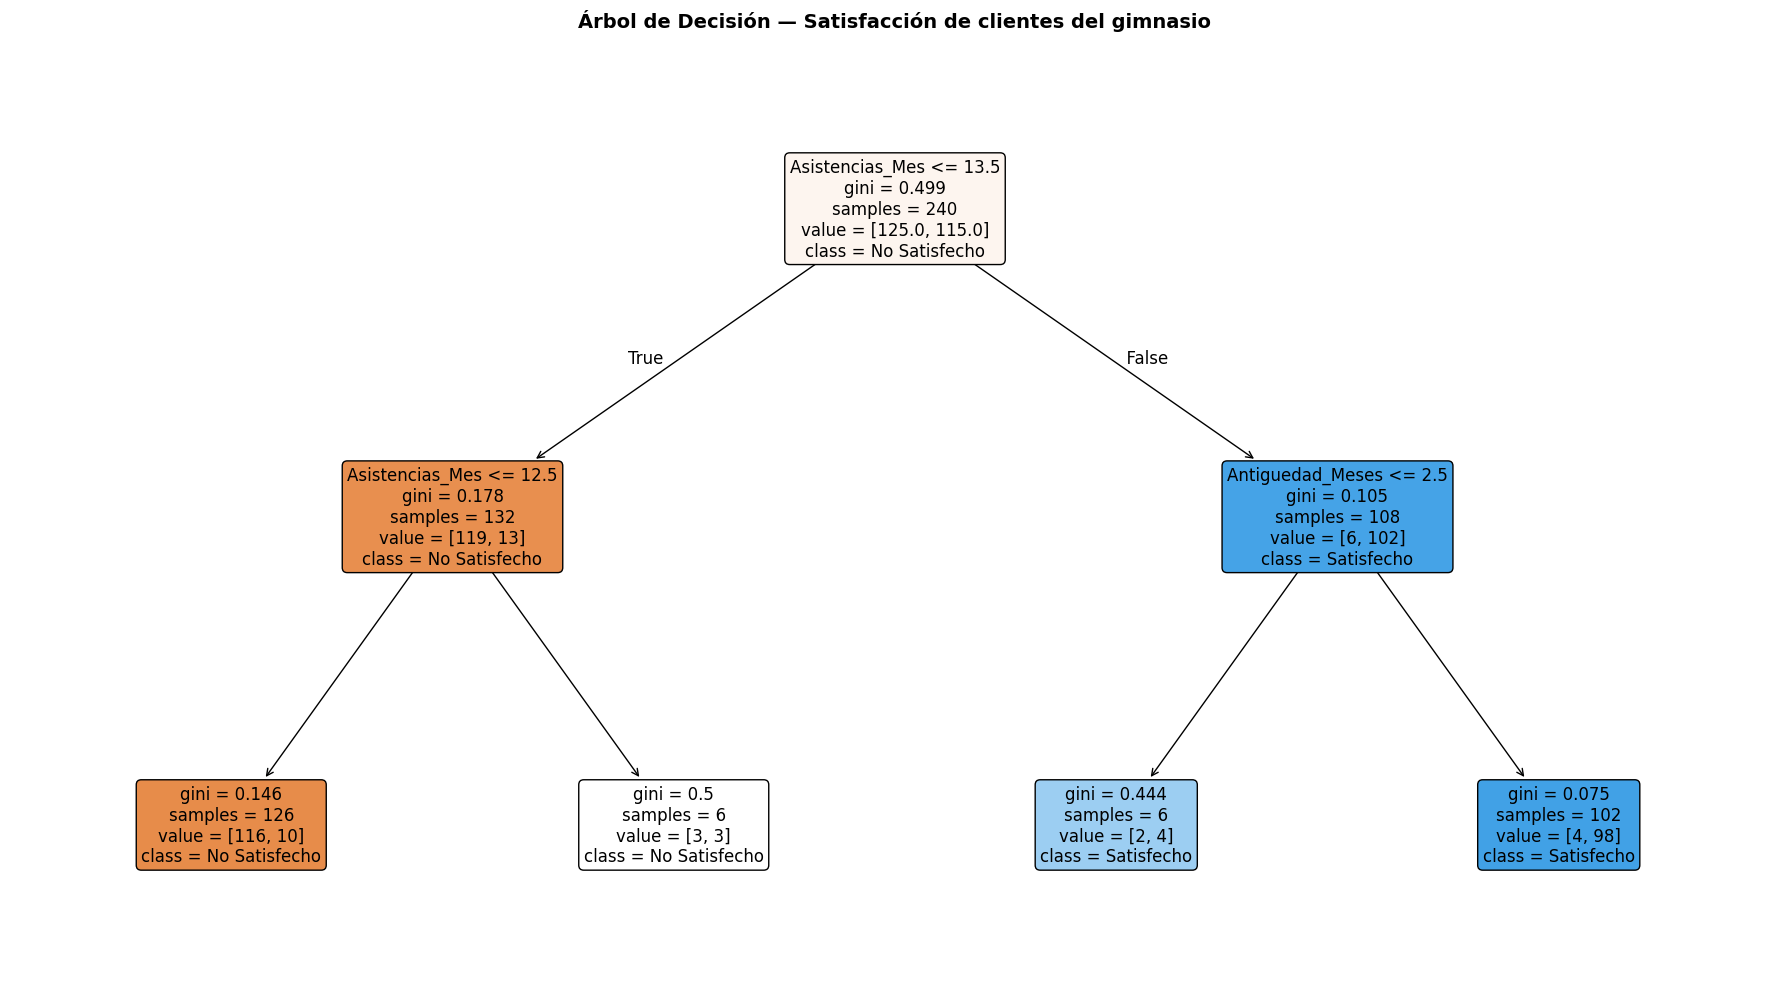

In [8]:
# ============================================================
# VISUALIZACIÓN DEL ÁRBOL
# ============================================================
plt.figure(figsize=(18, 10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=["No Satisfecho", "Satisfecho"],
    filled=True,          # colorea los nodos según la clase dominante
    rounded=True,         # bordes redondeados (más legible)
    fontsize=12
)

plt.title("Árbol de Decisión — Satisfacción de clientes del gimnasio",
          fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

In [9]:
# ============================================================
# ÁRBOL EN FORMATO TEXTO — sin necesidad de gráficos
# ============================================================
rules = export_text(tree, feature_names=list(X.columns))
print("Reglas del árbol en texto plano:")
print(rules)

Reglas del árbol en texto plano:
|--- Asistencias_Mes <= 13.50
|   |--- Asistencias_Mes <= 12.50
|   |   |--- class: 0
|   |--- Asistencias_Mes >  12.50
|   |   |--- class: 0
|--- Asistencias_Mes >  13.50
|   |--- Antiguedad_Meses <= 2.50
|   |   |--- class: 1
|   |--- Antiguedad_Meses >  2.50
|   |   |--- class: 1



            Feature  Importancia
    Asistencias_Mes     0.988862
   Antiguedad_Meses     0.011138
     Horas_Pico_Mes     0.000000
Gasto_Mensual_Extra     0.000000

Features con importancia = 0.0 fueron ignoradas por el modelo.
Esto es un hallazgo de negocio: esas variables no predicen satisfacción.


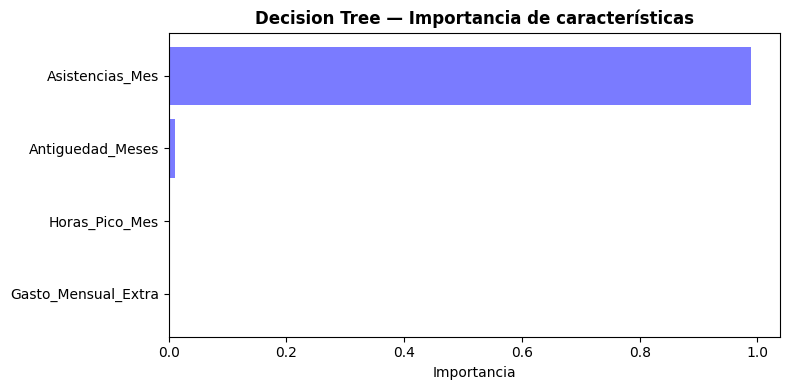

In [10]:
# ============================================================
# IMPORTANCIA DE FEATURES — DECISION TREE
# ============================================================
importances_tree = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importancia": tree.feature_importances_
}).sort_values("Importancia", ascending=False)

print(importances_tree.to_string(index=False))
print()
print("Features con importancia = 0.0 fueron ignoradas por el modelo.")
print("Esto es un hallazgo de negocio: esas variables no predicen satisfacción.")

plt.figure(figsize=(8, 4))
plt.barh(importances_tree["Feature"], importances_tree["Importancia"], color="#7a7bff")
plt.xlabel("Importancia")
plt.title("Decision Tree — Importancia de características", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

---
### 📌 Conclusiones — Decision Tree

#### Interpretación del árbol

**Raíz (primera pregunta):** `Asistencias_Mes ≤ 13.5`

**Rama IZQUIERDA** (SÍ, viene ≤ 13.5 veces/mes → 132 clientes):
- Gini = 0.178 → mayoría No Satisfechos [119, 13]
- Segunda pregunta: `Asistencias_Mes ≤ 12.5`
  - **SÍ** (viene poco): [116, 10] → **116 No Satisfechos** · 10 Satisfechos
  - **NO** (entre 12.5 y 13.5): [3, 3] → **empate** (Gini = 0.5, el modelo no sabe)

**Rama DERECHA** (NO, viene > 13.5 veces/mes → 108 clientes):
- Gini = 0.105 → mayoría Satisfechos [6, 102]
- Segunda pregunta: `Antigüedad_Meses ≤ 2.5`
  - **SÍ** (lleva menos de 2.5 meses): [2, 4] → 4 Satisfechos · 2 No Satisfechos
  - **NO** (lleva más de 2.5 meses): [4, 98] → **98 Satisfechos** (casi certeza total)

#### Hallazgo de negocio
- `Horas_Pico_Mes` y `Gasto_Mensual_Extra` → **importancia 0.0** → no predicen satisfacción

#### Acción recomendada
- **Clientes con < 13.5 visitas/mes** → campaña de activación inmediata
- **Clientes con > 13.5 visitas y > 2.5 meses** → programa VIP de fidelización


---
## 🌲🌲 Sección 3 — Random Forest Classifier

### ¿Qué es Random Forest?

Imagina que en vez de preguntarle a **1 árbol**, le preguntas a **100 árboles distintos**,  
cada uno entrenado con datos ligeramente diferentes.  
Al final, **gana la clase que más árboles hayan votado**.

Es como preguntar a 100 médicos en vez de a 1 solo:  
la opinión mayoritaria suele ser más fiable.

### ¿Por qué es mejor que un árbol solo?
- Un árbol puede tener mala suerte con los datos (overfitting)
- 100 árboles se ‘compensan’ entre sí → resultado más robusto
- Desventaja: menos interpretable


In [11]:
# ============================================================
# RANDOM FOREST — Entrenamiento
# ============================================================
rf = RandomForestClassifier(
    n_estimators=100,   # número de árboles en el bosque
    random_state=42     # semilla para reproducibilidad
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest entrenado correctamente ✓")
print(f"Número de árboles: {rf.n_estimators}")

Random Forest entrenado correctamente ✓
Número de árboles: 100


In [12]:
# ============================================================
# MÉTRICAS DE EVALUACIÓN — RANDOM FOREST
# ============================================================
print("=" * 50)
print("  RANDOM FOREST — Métricas de evaluación")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2%}")
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=["No Satisfecho", "Satisfecho"]   # ← consistente con los demás modelos
))

  RANDOM FOREST — Métricas de evaluación
Accuracy: 90.00%

Matriz de confusión:
[[28  3]
 [ 3 26]]

Reporte de clasificación:
               precision    recall  f1-score   support

No Satisfecho       0.90      0.90      0.90        31
   Satisfecho       0.90      0.90      0.90        29

     accuracy                           0.90        60
    macro avg       0.90      0.90      0.90        60
 weighted avg       0.90      0.90      0.90        60



            Feature  Importancia
    Asistencias_Mes     0.518544
     Horas_Pico_Mes     0.263940
Gasto_Mensual_Extra     0.152823
   Antiguedad_Meses     0.064693


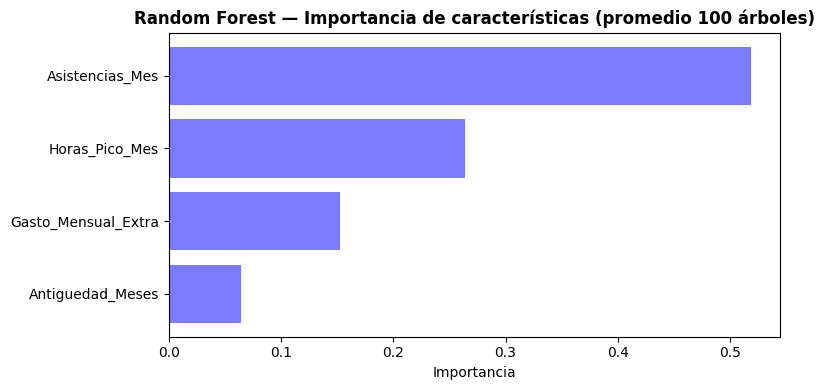


La importancia del RF es más fiable porque promedia 100 estimaciones independientes.


In [13]:
# ============================================================
# IMPORTANCIA DE FEATURES — RANDOM FOREST
# Más fiable que la del árbol: promedia 100 estimaciones
# ============================================================
importances_rf = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importancia": rf.feature_importances_
}).sort_values("Importancia", ascending=False)

print(importances_rf.to_string(index=False))

plt.figure(figsize=(8, 4))
plt.barh(importances_rf["Feature"], importances_rf["Importancia"], color="#7a7bff")
plt.xlabel("Importancia")
plt.title("Random Forest — Importancia de características (promedio 100 árboles)",
          fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print()
print("La importancia del RF es más fiable porque promedia 100 estimaciones independientes.")

---
### 📌 Conclusiones — Random Forest

- Usa los mismos datos que el Decision Tree pero con más árboles
- La importancia de features confirma o corrige lo del árbol individual
- Si ambos modelos coinciden en qué features importan → el hallazgo es más sólido
- **Desventaja clave:** no se puede visualizar → menor interpretabilidad


---
## ⚡ Sección 4 — XGBoost Classifier

### ¿Qué es XGBoost?

Random Forest entrena 100 árboles **en paralelo** (independientes entre sí).  
XGBoost los entrena **en secuencia**: cada árbol aprende de los **errores** del anterior.

Es como un equipo donde el segundo jugador corrige los fallos del primero.  
Resultado: suele ser el modelo más preciso de los tres.

| Modelo | Cómo entrena |
|---|---|
| Decision Tree | 1 árbol |
| Random Forest | 100 árboles en paralelo, votan |
| XGBoost | 200 árboles en secuencia, aprenden del error |


In [14]:
from xgboost import XGBClassifier, plot_importance, to_graphviz

In [15]:
# ============================================================
# XGBOOST — Definición del modelo con parámetros comentados
# ============================================================
xgb_model = XGBClassifier(
    n_estimators=200,        # número de árboles
    max_depth=4,             # profundidad de cada árbol individual
    learning_rate=0.1,       # cuánto aprende en cada iteración (0.01 lento, 0.3 rápido)
    subsample=0.8,           # usa el 80% de las filas por árbol → reduce overfitting
    colsample_bytree=0.8,    # usa el 80% de las features por árbol → reduce overfitting
    random_state=42,         # semilla para reproducibilidad
    eval_metric="logloss"    # métrica interna durante el entrenamiento
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost entrenado correctamente ✓")

XGBoost entrenado correctamente ✓


In [16]:
# ============================================================
# MÉTRICAS DE EVALUACIÓN — XGBOOST
# ============================================================
print("=" * 50)
print("  XGBOOST — Métricas de evaluación")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.2%}")
print()
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb))
print()
print("Reporte de clasificación:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["No Satisfecho", "Satisfecho"]   # ← importante: nombrar las clases
))

  XGBOOST — Métricas de evaluación
Accuracy: 88.33%

Matriz de confusión:
[[28  3]
 [ 4 25]]

Reporte de clasificación:
               precision    recall  f1-score   support

No Satisfecho       0.88      0.90      0.89        31
   Satisfecho       0.89      0.86      0.88        29

     accuracy                           0.88        60
    macro avg       0.88      0.88      0.88        60
 weighted avg       0.88      0.88      0.88        60



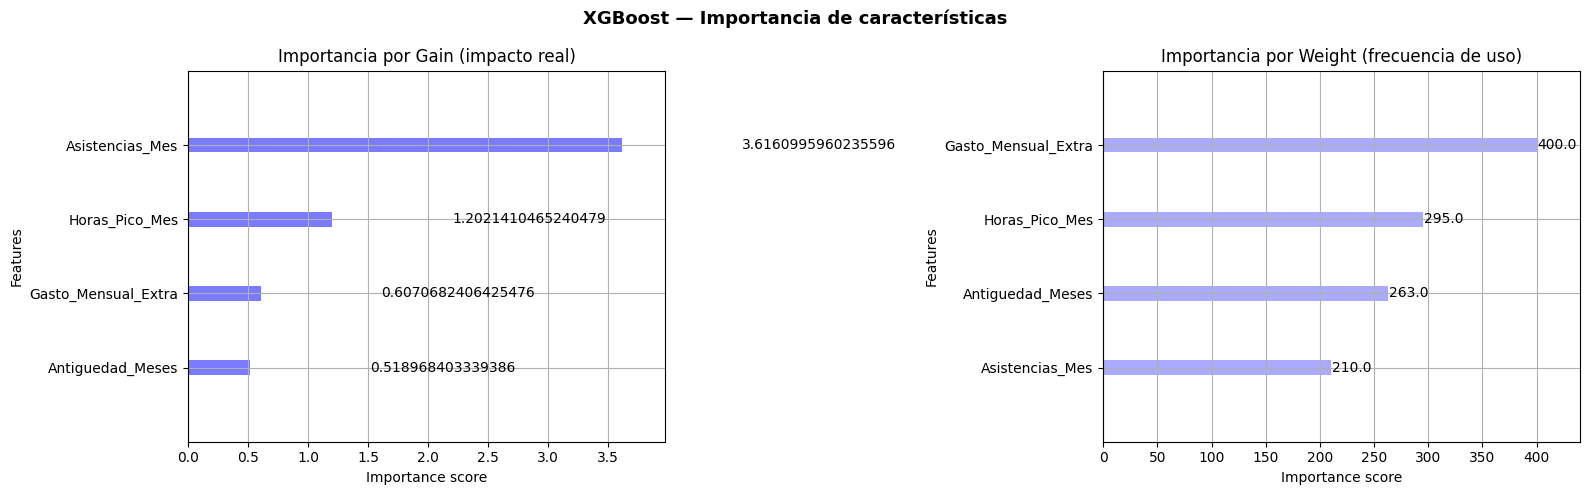

Gain = métrica profesional. Mide cuánto mejora el modelo cada feature.
Weight = cuántas veces aparece una feature. No mide impacto real.


In [17]:
# ============================================================
# IMPORTANCIA DE CARACTERÍSTICAS — XGBOOST
# gain = impacto real | weight = frecuencia de aparición
# En producción siempre usamos gain
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_importance(xgb_model,
                importance_type="gain",
                ax=axes[0],
                title="Importancia por Gain (impacto real)",
                color="#7a7bff")

plot_importance(xgb_model,
                importance_type="weight",
                ax=axes[1],
                title="Importancia por Weight (frecuencia de uso)",
                color="#aaaaff")

plt.suptitle("XGBoost — Importancia de características", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Gain = métrica profesional. Mide cuánto mejora el modelo cada feature.")
print("Weight = cuántas veces aparece una feature. No mide impacto real.")

In [18]:
# ============================================================
# ÁRBOL EN TEXTO — sin Graphviz, siempre funciona
# ============================================================
print("=== Estructura del árbol nº 0 ===")
print(xgb_model.get_booster().get_dump()[0])

=== Estructura del árbol nº 0 ===
0:[Asistencias_Mes<14] yes=1,no=2,missing=2
	1:[Horas_Pico_Mes<13.9057846] yes=3,no=4,missing=4
		3:leaf=-0.161862984
		4:[Horas_Pico_Mes<14.6793499] yes=5,no=6,missing=6
			5:leaf=0.0235108286
			6:leaf=-0.127023369
	2:leaf=0.17749241



In [22]:
# ============================================================
# GRAPHVIZ — requiere instalación extra en Windows
# Instalar: pip install graphviz
# + descargar desde graphviz.org y marcar 'Add to PATH'
# ============================================================
try:
    graph = to_graphviz(xgb_model, num_trees=0)  # num_trees es keyword, no variable
    graph   # debe ser la última línea de la celda para que Jupyter lo renderice
except Exception as e:
    print(f"Graphviz no disponible: {e}")
    print("Instala desde: https://graphviz.org/download/")

c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\plotting.py:268: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


---
### 📌 Conclusiones — XGBoost

- XGBoost es el más potente pero el menos interpretable de los tres
- `subsample=0.8` y `colsample_bytree=0.8` son **regularización**: evitan memorizar el train
- Si su accuracy no supera al RF, el problema ya está bien resuelto con modelos más simples
- **En entrevistas:** explica por qué elegiste XGBoost, no solo que lo usaste


---
## 📊 Sección 5 — Comparativa final de los 3 modelos

Esta tabla es lo primero que pregunta cualquier recruiter o director.


In [20]:
# ============================================================
# TABLA COMPARATIVA — los 3 modelos frente a frente
# ============================================================
acc_tree = accuracy_score(y_test, y_pred_tree)
acc_rf   = accuracy_score(y_test, y_pred_rf)
acc_xgb  = accuracy_score(y_test, y_pred_xgb)

resultados = pd.DataFrame({
    "Modelo":        ["Decision Tree", "Random Forest", "XGBoost"],
    "Accuracy":      [f"{acc_tree:.2%}", f"{acc_rf:.2%}", f"{acc_xgb:.2%}"],
    "Interpretable": ["✅ Sí (dibujas el árbol)", "⚠️ Parcial (feature importance)", "❌ No (caja negra)"],
    "Velocidad":     ["⚡ Muy rápido", "🐢 Medio", "🐢 Medio"],
    "Overfitting":   ["⚠️ Riesgo alto", "✅ Bajo riesgo", "✅ Controlado"],
    "Mejor para":    ["Presentar a dirección", "Producción robusta", "Máxima accuracy"]
})

print(resultados.to_string(index=False))

       Modelo Accuracy                   Interpretable    Velocidad    Overfitting            Mejor para
Decision Tree   90.00%         ✅ Sí (dibujas el árbol) ⚡ Muy rápido ⚠️ Riesgo alto Presentar a dirección
Random Forest   90.00% ⚠️ Parcial (feature importance)      🐢 Medio  ✅ Bajo riesgo    Producción robusta
      XGBoost   88.33%               ❌ No (caja negra)      🐢 Medio   ✅ Controlado       Máxima accuracy


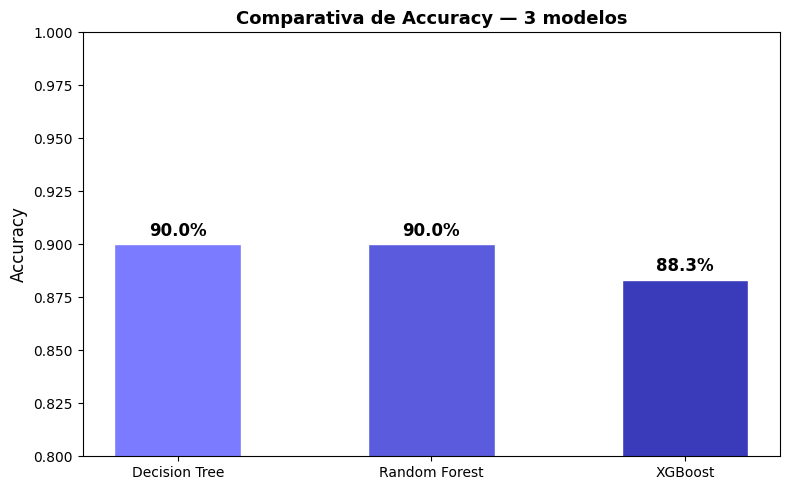

In [21]:
# ============================================================
# GRÁFICO COMPARATIVO
# ============================================================
modelos    = ["Decision Tree", "Random Forest", "XGBoost"]
accuracies = [acc_tree, acc_rf, acc_xgb]
colores    = ["#7a7bff", "#5a5bdd", "#3a3bbb"]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accuracies, color=colores, width=0.5, edgecolor="white")
plt.ylim(0.80, 1.0)
plt.ylabel("Accuracy", fontsize=12)
plt.title("Comparativa de Accuracy — 3 modelos", fontsize=13, fontweight="bold")

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f"{acc:.1%}", ha="center", va="bottom", fontweight="bold", fontsize=12)

plt.tight_layout()
plt.show()

---
## 🎯 Sección 6 — Conclusión de negocio

Un Data Analyst no entrega modelos. Entrega **decisiones**.

---

### ¿Qué modelo llevarías a producción?

**Respuesta: Decision Tree (depth=2)**

A pesar de que Random Forest o XGBoost podrían tener igual o mayor accuracy,  
el Decision Tree ofrece:
- **Reglas completamente explicables** a cualquier responsable del gimnasio
- **90% de accuracy con solo 2 preguntas** → señal de que el problema tiene estructura clara
- **Mantenimiento trivial** → cualquier persona puede auditarlo

> **Regla de oro:** Si la diferencia de accuracy entre DT y XGBoost es < 2%, **siempre gana el modelo simple**.

---

### Hallazgos clave para el negocio

| Hallazgo | Implicación |
|---|---|
| Feature más importante: `Asistencias_Mes` | Fidelizar = conseguir que vengan más frecuente |
| `Gasto_Mensual_Extra` con importancia 0 | No invertir en upselling para retener clientes |
| Umbral crítico: 13.5 visitas/mes | KPI de salud: si baja de 13, activar alerta |
| > 13.5 visitas + > 2.5 meses = 98% satisfechos | Segmento VIP a cuidar y renovar |

### Acciones recomendadas

1. **Alerta automática** → cliente con < 13 visitas este mes → email de reactivación
2. **Programa VIP** → cliente con > 13 visitas y > 2.5 meses → oferta de renovación anticipada
3. **No gastar en extra-services** → `Gasto_Mensual_Extra` no predice satisfacción
4. **KPI en Power BI** → % de clientes en zona de riesgo (< 13.5 visitas/mes) en tiempo real


---

## ✅ Checklist — Buenas prácticas aplicadas

- [x] Todos los imports al inicio del notebook
- [x] Comentarios en todos los parámetros
- [x] `stratify=y` en el train/test split
- [x] `target_names` consistentes en los 3 modelos
- [x] Curva de validación para justificar `max_depth`
- [x] Feature importance en los 3 modelos
- [x] Conclusiones técnicas + conclusión de negocio
- [x] Tabla comparativa final de los 3 modelos
- [x] Try/except para dependencias opcionales (Graphviz)

---
*Notebook generado como ejercicio de aprendizaje de Machine Learning para Data Analysts*
